In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import skytools as st
import pymaster as nmt

#### Timeline of the number of telescopes from Sara Simon   


In [2]:
## SO nominal config: 0, 4, 2 tubes for LF, MF, HF. 
## ASO config: 1, 8, 4 tubes for LF, MF, HF.
## SO nominal config from 2025 to mid-2026, then ASO config from mid-2026 to 2035.
telescope_timeline = np.array([ ## baseline full SO Schedule. Tubes for each year
                           # 25    26    27    28    29    30    31    32    33    34    35
                            [0,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1], #f030 
                            [0,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1], #f040 
                            [4,    8,    8,    8,    8,    8,    8,    8,    8,    8,    8], #f090 
                            [4,    8,    8,    8,    8,    8,    8,    8,    8,    8,    8], #f150 
                            [2,    4,    4,    4,    4,    4,    4,    4,    4,    4,    4], #f220 
                            [2,    4,    4,    4,    4,    4,    4,    4,    4,    4,    4], #f280
                        ])  

In [3]:
telescope_years = np.sum(telescope_timeline, axis=1)

In [4]:
print(telescope_years)

[10 10 84 84 42 42]


In [5]:
frequencies   = np.array([  27,  39,   93,  145,   225,  280]) # in GHz
NET_telescope = np.array([  35,  18,  7.8,  8.4,  14.1, 35.4]) # in uK*sqrt(s)

In [6]:
nonpwv_obs_eff = 0.30

In [7]:
so_lf_hits = hp.read_map('/global/cfs/cdirs/sobs/sims/deso/unscaled/lat_wide_1_el/LAT_f030/lat_wide_1_el_LAT_f030_hits.fits')

so_lf_hits = hp.ud_grade(so_lf_hits, 2048, power=-2)

so_lf_bin  = np.zeros(so_lf_hits.shape)
so_lf_bin[so_lf_hits>min(so_lf_hits[so_lf_hits>0])] = 1.
so_lf_bin = st.mask_udgrade(so_lf_bin, 2048)


In [8]:
so_lf_hits[so_lf_hits < 0.] = 0.
so_lf_relhits = so_lf_hits / np.max(so_lf_hits)

/pscratch/sd/s/shamikg/cmbenv/master-0.0.1/conda/lib/python3.12/site-packages/healpy/visufunc.py:200: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


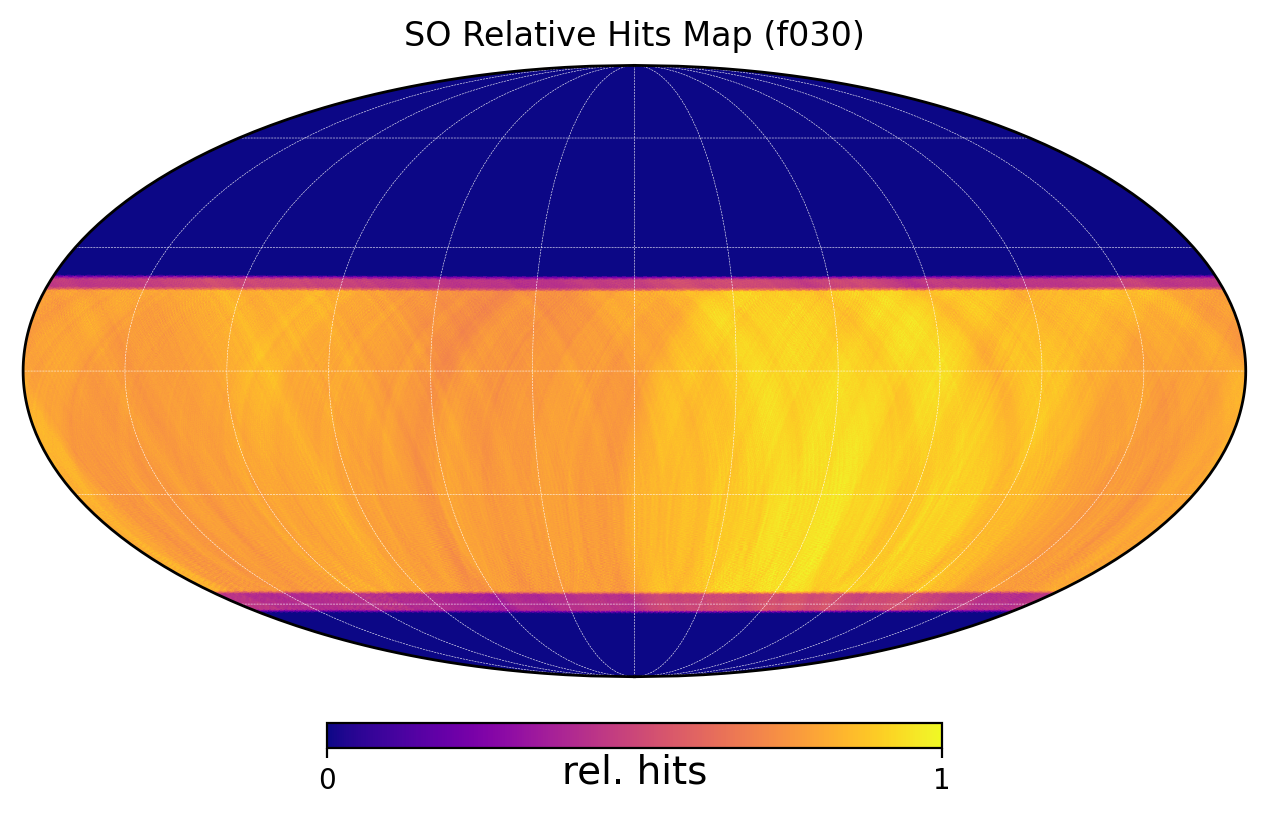

In [9]:
fig = plt.figure(dpi=200)
hp.mollview(so_lf_relhits, title='SO Relative Hits Map (f030)', unit='rel. hits', cmap='plasma', xsize=1200, fig=fig.number)
hp.graticule(30, 30, lw=0.2, ls='--', c='w')

In [10]:
so_mf_hits = hp.read_map('/global/cfs/cdirs/sobs/sims/deso/unscaled/lat_wide_1_el/LAT_f090/lat_wide_1_el_LAT_f090_hits.fits')
so_mf_hits = hp.ud_grade(so_mf_hits, 2048, power=-2)

so_mf_bin  = np.zeros(so_mf_hits.shape)
so_mf_bin[so_mf_hits>min(so_mf_hits[so_mf_hits>0])] = 1.
# so_mf_bin = st.mask_udgrade(so_mf_bin, 2048)

In [11]:
so_mf_hits[so_mf_hits < 0.] = 0.
so_mf_relhits = so_mf_hits / np.max(so_mf_hits)

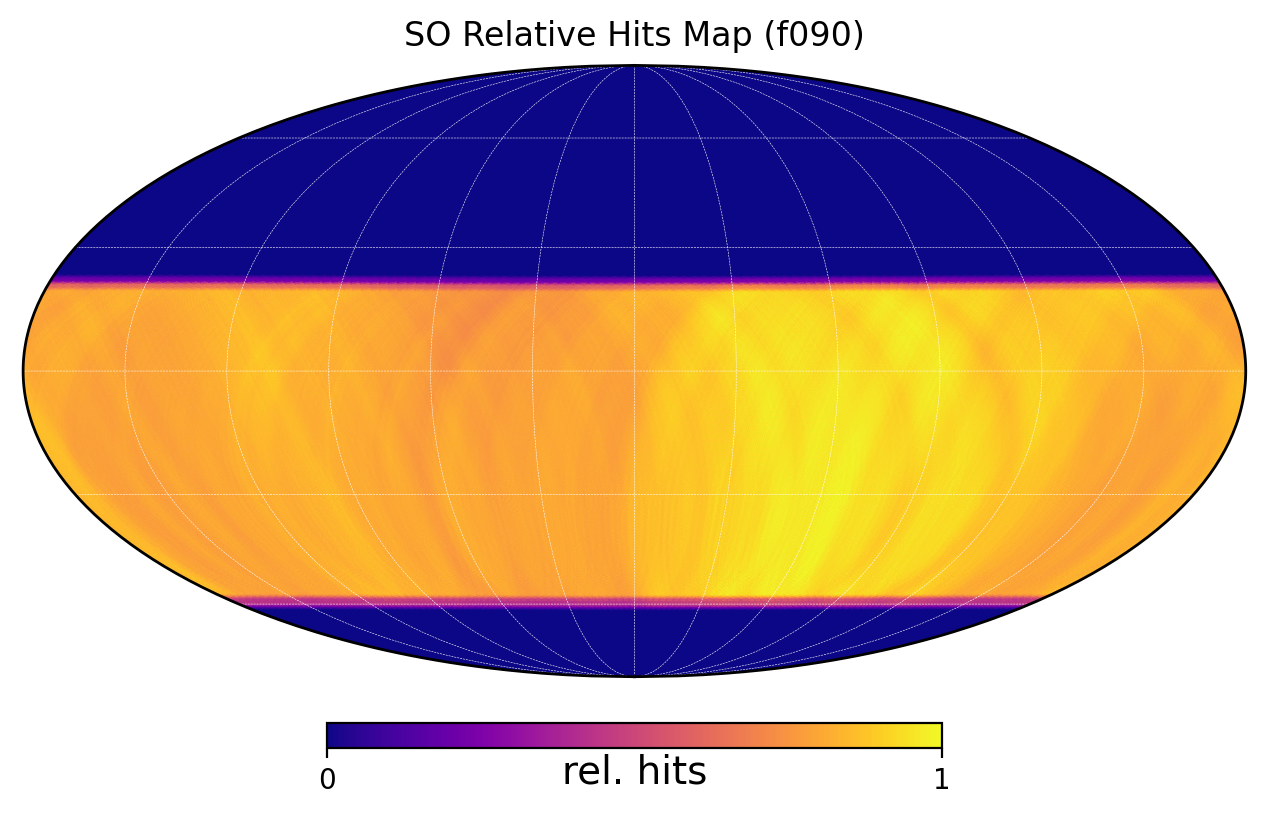

In [12]:
fig = plt.figure(dpi=200)
hp.mollview(so_mf_relhits, title='SO Relative Hits Map (f090)', unit='rel. hits', cmap='plasma', xsize=1200, fig=fig.number)
hp.graticule(30, 30, lw=0.2, ls='--', c='w')

In [13]:
so_uhf_hits = hp.read_map('/global/cfs/cdirs/sobs/sims/deso/unscaled/lat_wide_1_el/LAT_f090/lat_wide_1_el_LAT_f090_hits.fits')
so_uhf_hits = hp.ud_grade(so_uhf_hits, 2048, power=-2)

so_uhf_bin  = np.zeros(so_uhf_hits.shape)
so_uhf_bin[so_uhf_hits>min(so_uhf_hits[so_uhf_hits>0])] = 1.

In [14]:
so_uhf_hits[so_uhf_hits < 0.] = 0.
so_uhf_relhits = so_uhf_hits / np.max(so_uhf_hits)

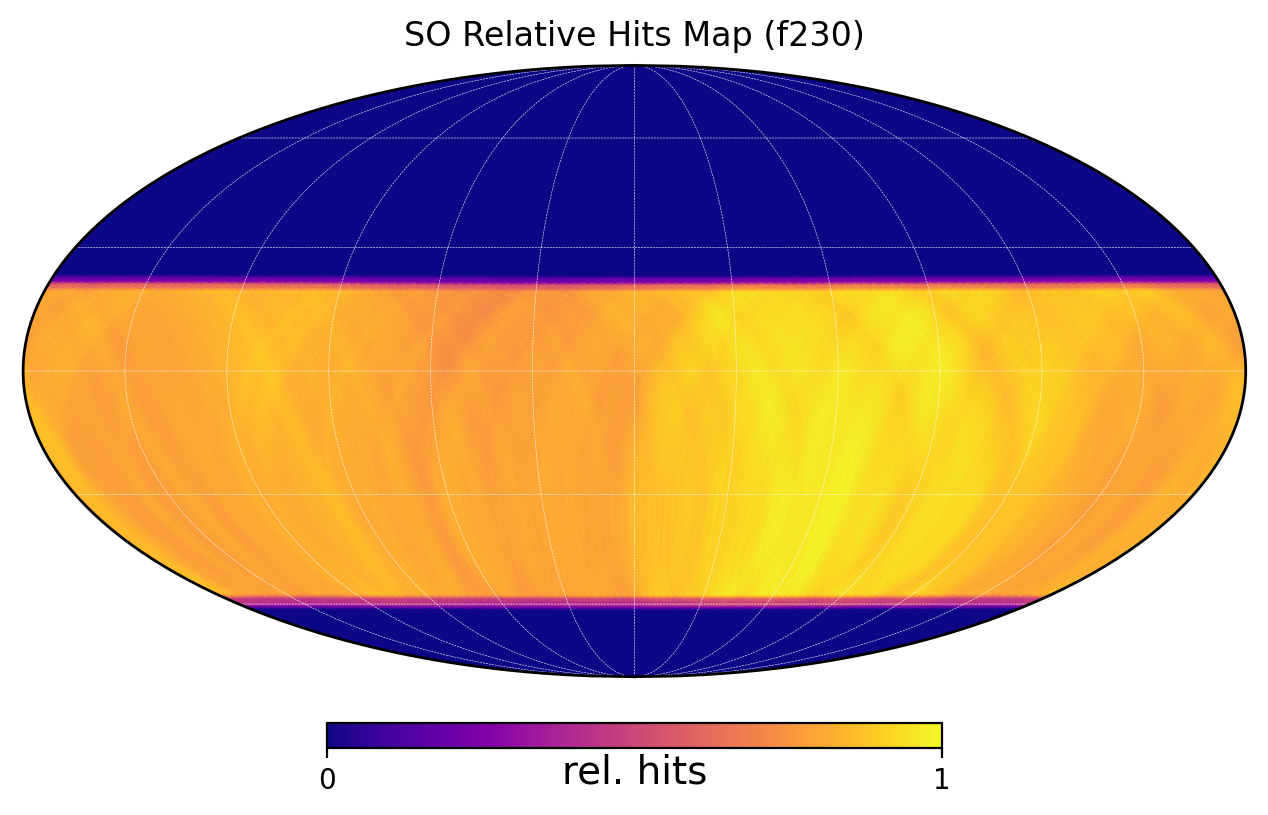

In [15]:
fig = plt.figure(dpi=200)
hp.mollview(so_uhf_relhits, title='SO Relative Hits Map (f230)', unit='rel. hits', cmap='plasma', xsize=1200, fig=fig.number)
hp.graticule(30, 30, lw=0.2, ls='--', c='w')

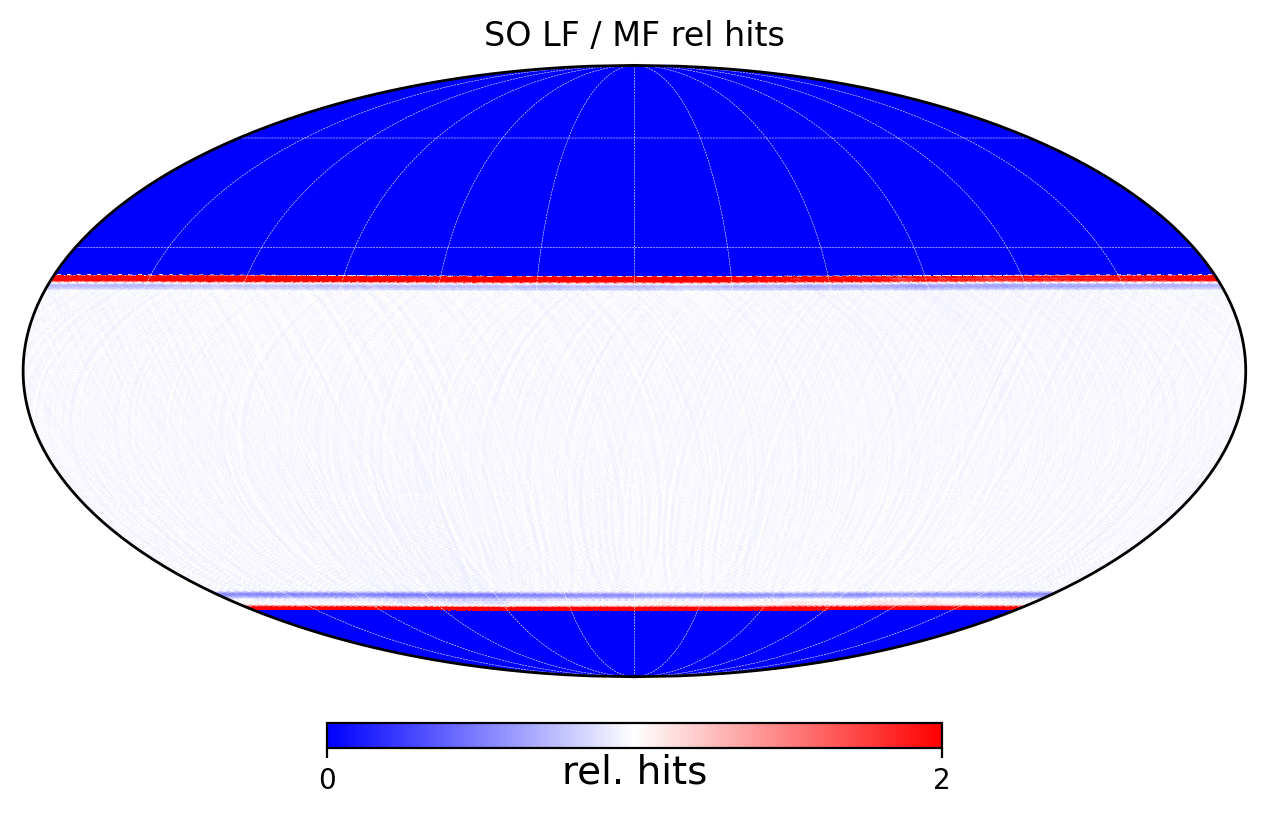

In [16]:
relhits_ratio = np.zeros_like(so_lf_relhits)
relhits_ratio[(so_lf_relhits > 0.) & (so_mf_relhits > 0.)] = so_lf_relhits[(so_lf_relhits > 0.) & (so_mf_relhits > 0.)] / so_mf_relhits[(so_lf_relhits > 0.) & (so_mf_relhits > 0.)]
fig = plt.figure(dpi=200)
hp.mollview(relhits_ratio, title='SO LF / MF rel hits', unit='rel. hits', cmap='bwr', xsize=1200, fig=fig.number, min=0., max=2.)
hp.graticule(30, 30, lw=0.2, ls='--', c='w')

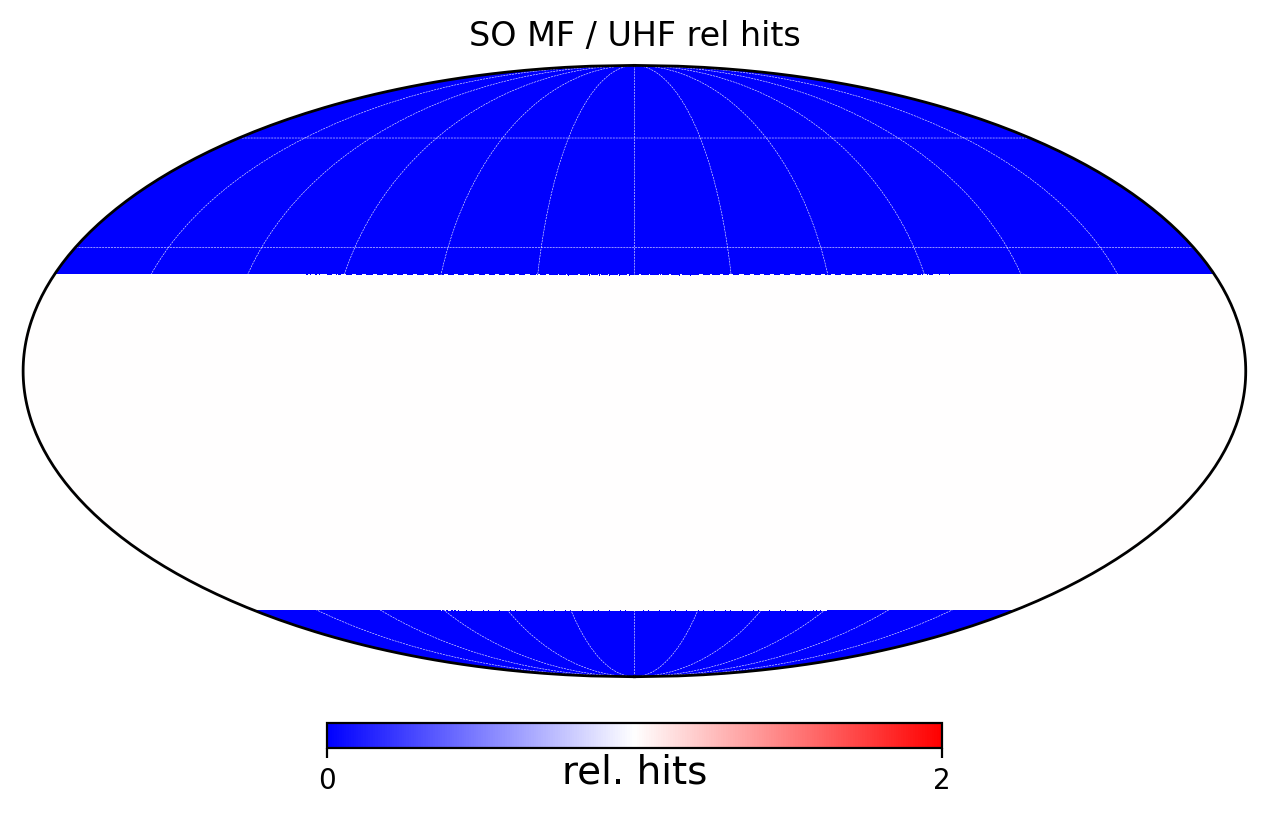

In [17]:
relhits_ratio = np.zeros_like(so_mf_relhits)
relhits_ratio[(so_mf_relhits > 0.) & (so_uhf_relhits > 0.)] = so_mf_relhits[(so_mf_relhits > 0.) & (so_uhf_relhits > 0.)] / so_uhf_relhits[(so_mf_relhits > 0.) & (so_uhf_relhits > 0.)]
fig = plt.figure(dpi=200)
hp.mollview(relhits_ratio, title='SO MF / UHF rel hits', unit='rel. hits', cmap='bwr', xsize=1200, fig=fig.number, min=0., max=2.)
hp.graticule(30, 30, lw=0.2, ls='--', c='w')

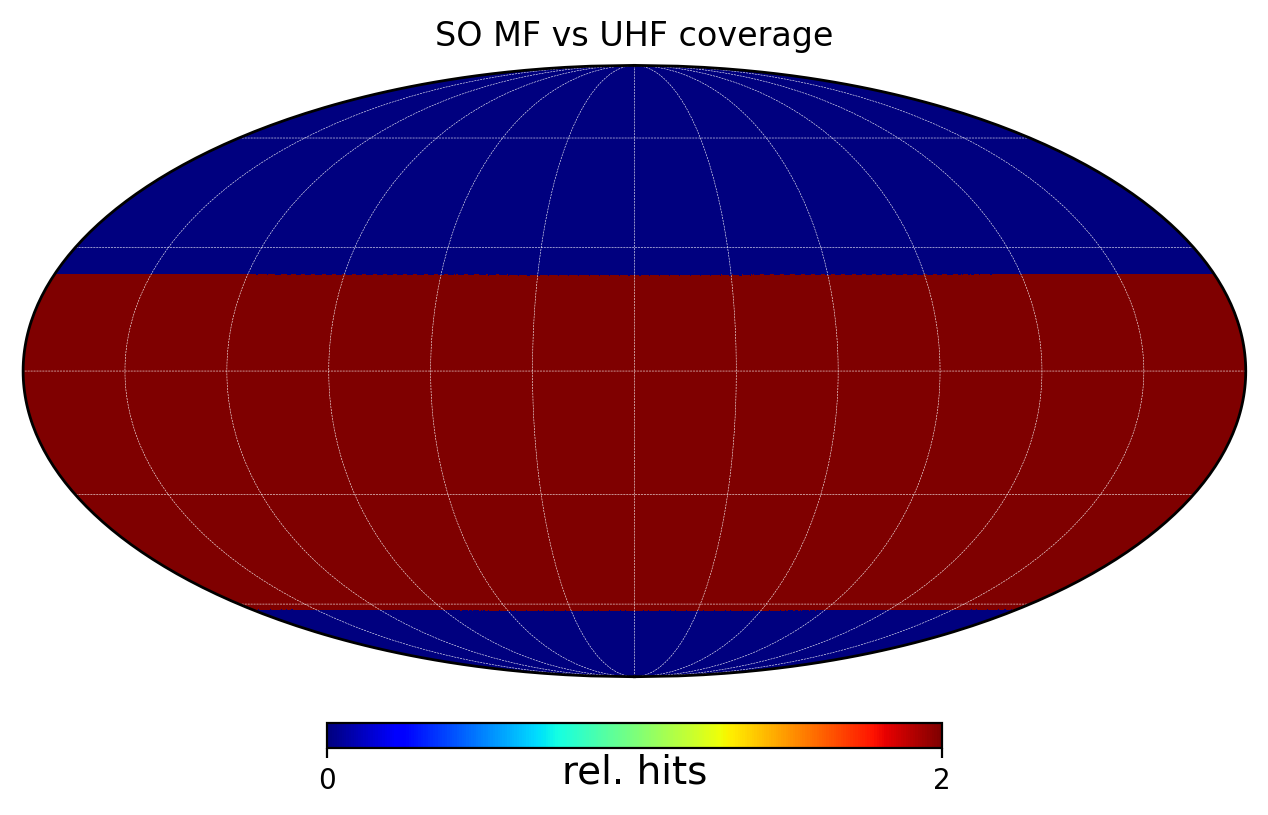

In [18]:
fig = plt.figure(dpi=200)
hp.mollview(so_mf_bin + so_uhf_bin, title='SO MF vs UHF coverage', unit='rel. hits', cmap='jet', xsize=1200, fig=fig.number)
hp.graticule(30, 30, lw=0.2, ls='--', c='w')

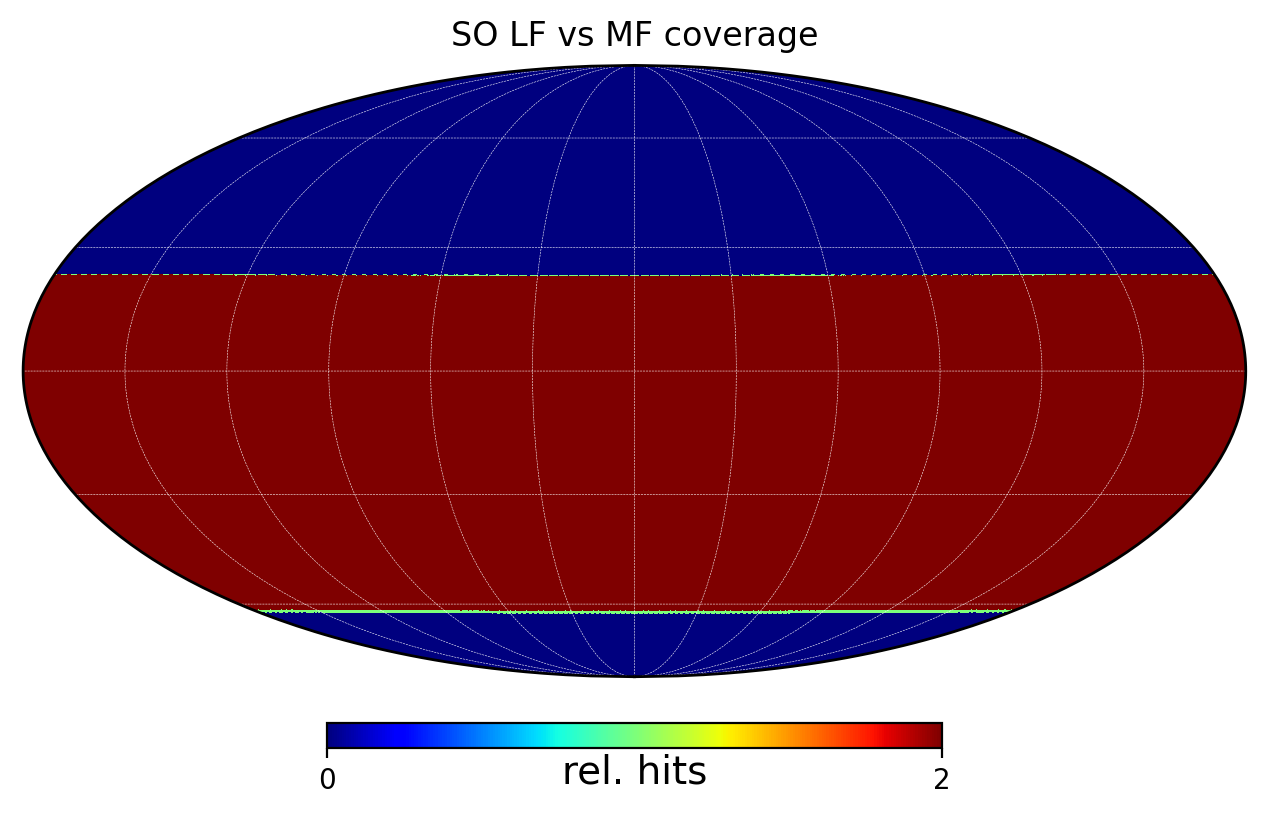

In [19]:
fig = plt.figure(dpi=200)
hp.mollview(so_mf_bin + so_lf_bin, title='SO LF vs MF coverage', unit='rel. hits', cmap='jet', xsize=1200, fig=fig.number)
hp.graticule(30, 30, lw=0.2, ls='--', c='w')

In [20]:
tobs_tot_in_s = telescope_years * 365.25 * 24 * 60 * 60

tobs_per_pix_lf = tobs_tot_in_s[0] * so_lf_relhits / np.sum(so_lf_relhits)
print("t_obs per pixel LF", np.mean(tobs_per_pix_lf[so_lf_relhits > 0.]), "s")

tobs_per_pix_mf = tobs_tot_in_s[2] * so_mf_relhits / np.sum(so_mf_relhits)
print("t_obs per pixel MF", np.mean(tobs_per_pix_mf[so_mf_relhits > 0.]), "s")

tobs_per_pix_hf = tobs_tot_in_s[4] * so_uhf_relhits / np.sum(so_uhf_relhits)
print("t_obs per pixel HF", np.mean(tobs_per_pix_hf[so_uhf_relhits > 0.]), "s")

t_obs per pixel LF 9.779581952435636 s
t_obs per pixel MF 82.42312261577128 s
t_obs per pixel HF 41.21156130788564 s


In [21]:
def varpix2uKarcmin(var_map):
    nside_in = hp.get_nside(var_map)
    pixarea_deg = hp.nside2pixarea(nside_in, degrees=True)

    return 60. * np.sqrt(var_map * pixarea_deg) 

The $\sqrt2$ factor is included to convert from NET to NEQ/U

Note: `detector_yield` is already included for all channels other than 346 GHz 

In [22]:
so_f093_noise_var = np.zeros_like(so_mf_relhits)
so_f093_noise_var[so_mf_relhits > 0.] = (np.sqrt(2) * NET_telescope[2])**2. / (tobs_per_pix_mf[so_mf_relhits > 0.] * nonpwv_obs_eff)# * modeloss_penalty)

so_f145_noise_var = np.zeros_like(so_mf_relhits)
so_f145_noise_var[so_mf_relhits > 0.] = (np.sqrt(2) * NET_telescope[3])**2. / (tobs_per_pix_mf[so_mf_relhits > 0.] * nonpwv_obs_eff)# * modeloss_penalty)

In [23]:
so_f027_noise_var = np.zeros_like(so_lf_relhits)
so_f027_noise_var[so_lf_relhits > 0.] = (np.sqrt(2) * NET_telescope[0])**2. / (tobs_per_pix_lf[so_lf_relhits > 0.] * nonpwv_obs_eff)# * modeloss_penalty)

so_f039_noise_var = np.zeros_like(so_lf_relhits)
so_f039_noise_var[so_lf_relhits > 0.] = (np.sqrt(2) * NET_telescope[1])**2. / (tobs_per_pix_lf[so_lf_relhits > 0.] * nonpwv_obs_eff)# * modeloss_penalty)

In [24]:
so_f225_noise_var = np.zeros_like(so_uhf_relhits)
so_f225_noise_var[so_uhf_relhits > 0.] = (np.sqrt(2) * NET_telescope[4])**2. / (tobs_per_pix_hf[so_uhf_relhits > 0.] * nonpwv_obs_eff)# * modeloss_penalty)

so_f280_noise_var = np.zeros_like(so_uhf_relhits)
so_f280_noise_var[so_uhf_relhits > 0.] = (np.sqrt(2) * NET_telescope[5])**2. / (tobs_per_pix_hf[so_uhf_relhits > 0.] * nonpwv_obs_eff)# * modeloss_penalty)


In [25]:
print("uK-arcmin (f027) :", np.mean(varpix2uKarcmin(so_f027_noise_var)[so_mf_relhits == 1.]))
print("uK-arcmin (f039) :", np.mean(varpix2uKarcmin(so_f039_noise_var)[so_mf_relhits == 1.]))
print("uK-arcmin (f093) :", np.mean(varpix2uKarcmin(so_f093_noise_var)[so_mf_relhits == 1]))
print("uK-arcmin (f145) :", np.mean(varpix2uKarcmin(so_f145_noise_var)[so_mf_relhits == 1]))
print("uK-arcmin (f225) :", np.mean(varpix2uKarcmin(so_f225_noise_var)[so_uhf_relhits == 1]))
print("uK-arcmin (f280) :", np.mean(varpix2uKarcmin(so_f280_noise_var)[so_uhf_relhits == 1]))


uK-arcmin (f027) : 44.99574868687046
uK-arcmin (f039) : 23.140670753247665
uK-arcmin (f093) : 3.4284767129071323
uK-arcmin (f145) : 3.6922056908230654
uK-arcmin (f225) : 8.764773787948416
uK-arcmin (f280) : 22.005176744210925


In [26]:
hp.write_map(f'../resources/variance_maps/so_lat_wide_1_el_f027_noise_var_{telescope_years[0]:.2f}tel-yrs.fits', so_f027_noise_var, overwrite=True, column_names=['pol noise var pix'], column_units=['uK_CMB^2'],)
hp.write_map(f'../resources/variance_maps/so_lat_wide_1_el_f039_noise_var_{telescope_years[1]:.2f}tel-yrs.fits', so_f039_noise_var, overwrite=True, column_names=['pol noise var pix'], column_units=['uK_CMB^2'],)
hp.write_map(f'../resources/variance_maps/so_lat_wide_1_el_f093_noise_var_{telescope_years[2]:.2f}tel-yrs.fits', so_f093_noise_var, overwrite=True, column_names=['pol noise var pix'], column_units=['uK_CMB^2'],)
hp.write_map(f'../resources/variance_maps/so_lat_wide_1_el_f145_noise_var_{telescope_years[3]:.2f}tel-yrs.fits', so_f145_noise_var, overwrite=True, column_names=['pol noise var pix'], column_units=['uK_CMB^2'],)
hp.write_map(f'../resources/variance_maps/so_lat_wide_1_el_f225_noise_var_{telescope_years[4]:.2f}tel-yrs.fits', so_f225_noise_var, overwrite=True, column_names=['pol noise var pix'], column_units=['uK_CMB^2'],)
hp.write_map(f'../resources/variance_maps/so_lat_wide_1_el_f280_noise_var_{telescope_years[5]:.2f}tel-yrs.fits', so_f280_noise_var, overwrite=True, column_names=['pol noise var pix'], column_units=['uK_CMB^2'],)


setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]


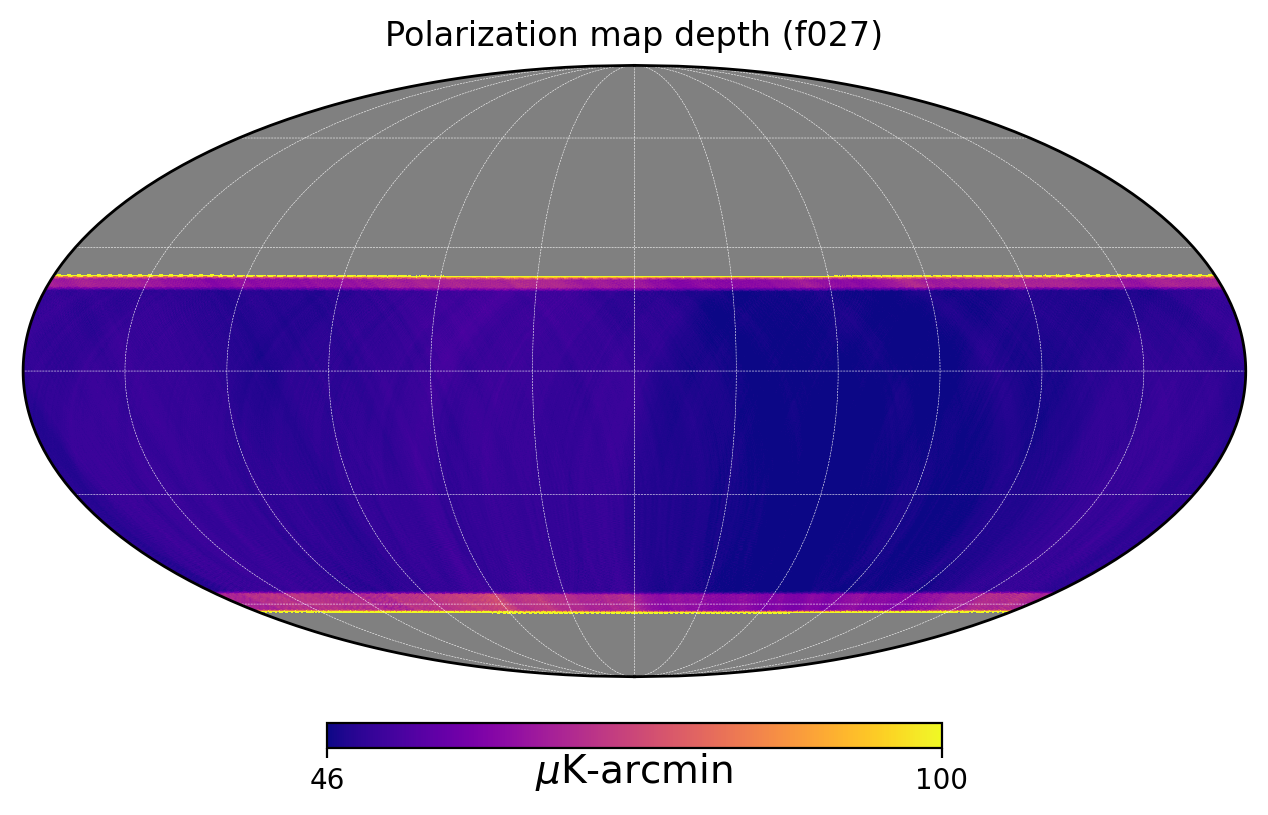

In [27]:
fig = plt.figure(dpi=200)
hp.mollview(varpix2uKarcmin(so_f027_noise_var) + (1 - so_lf_bin) * hp.UNSEEN, title='Polarization map depth (f027)', unit=r'$\mu$K-arcmin', cmap='plasma', xsize=1200, fig=fig.number, min=46., max=100.)
hp.graticule(30, 30, lw=0.2, ls='--', c='w')

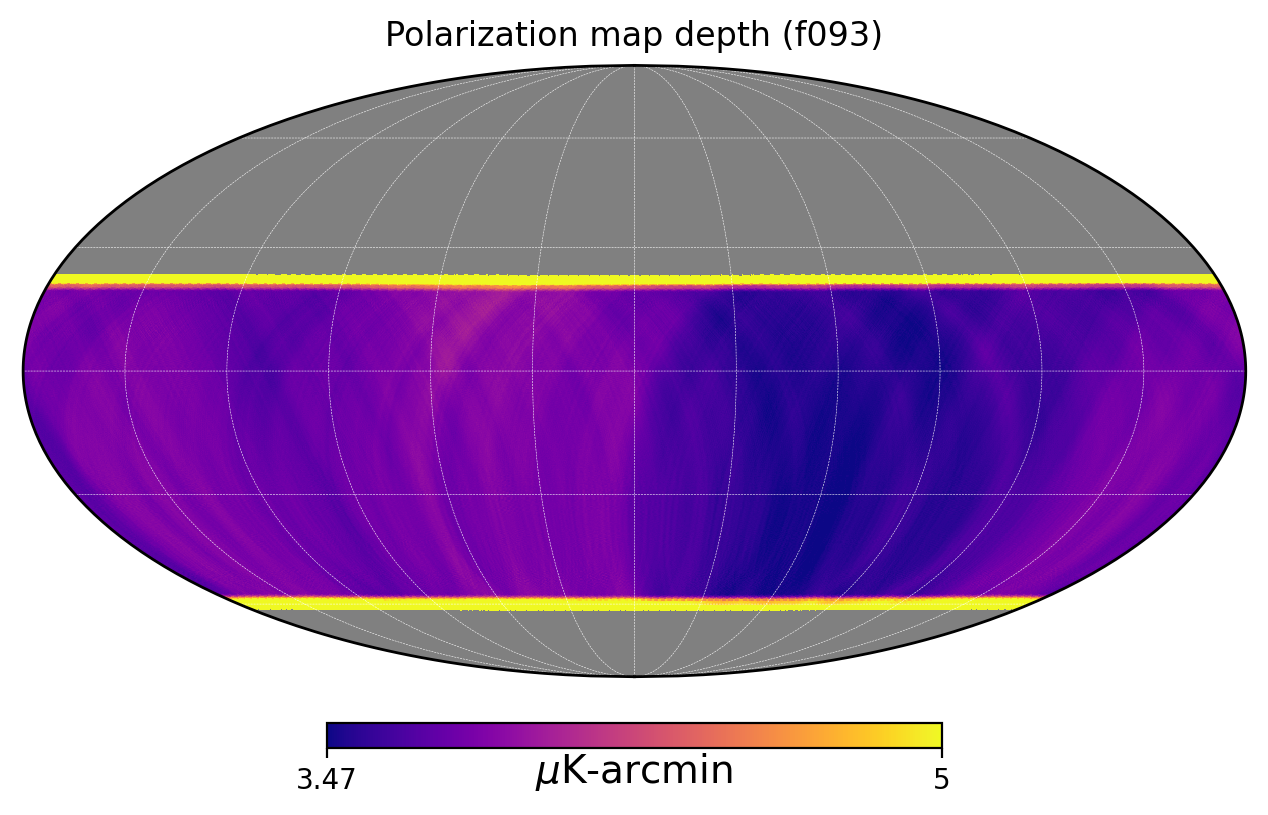

In [28]:
fig = plt.figure(dpi=200)
hp.mollview(varpix2uKarcmin(so_f093_noise_var) + (1 - so_mf_bin) * hp.UNSEEN, title='Polarization map depth (f093)', unit=r'$\mu$K-arcmin', cmap='plasma', xsize=1200, fig=fig.number, min=3.47, max=5.)
hp.graticule(30, 30, lw=0.2, ls='--', c='w')

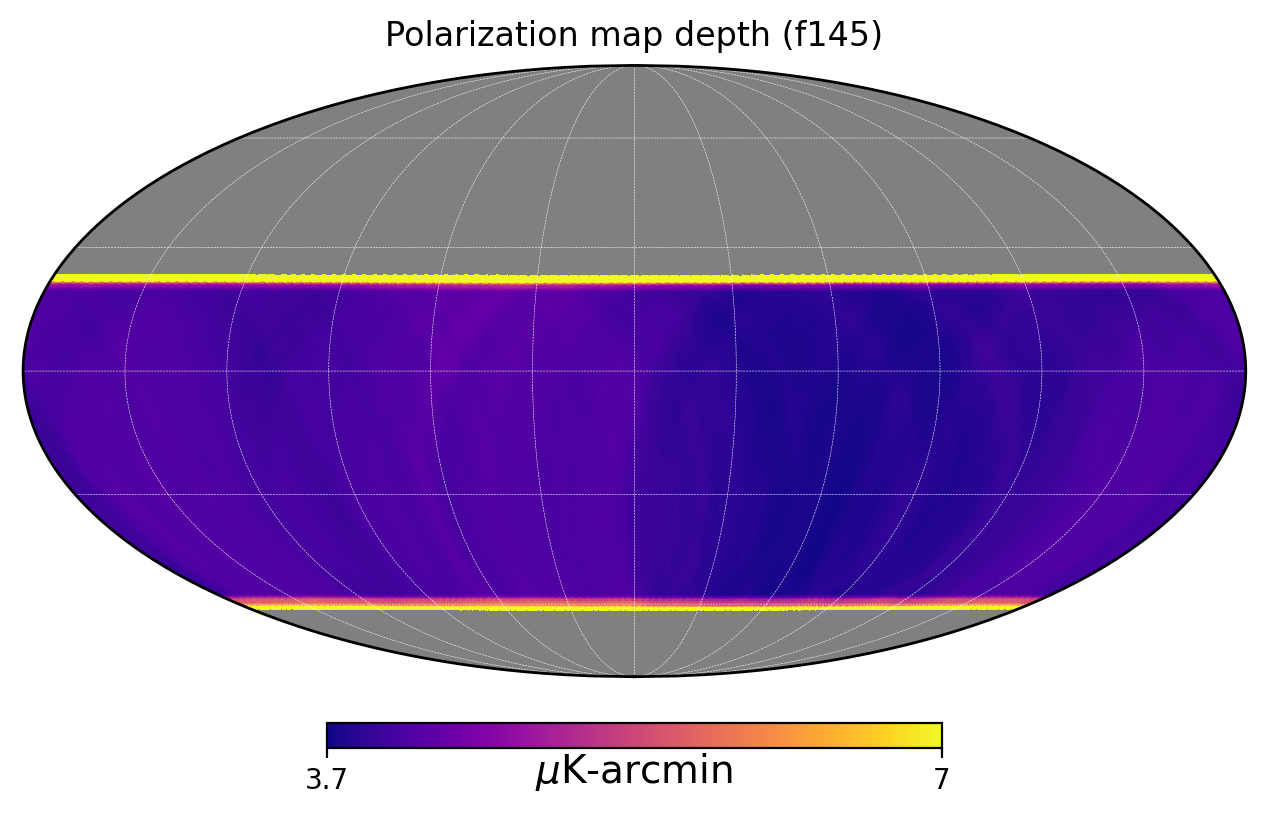

In [29]:
fig = plt.figure(dpi=200)
hp.mollview(varpix2uKarcmin(so_f145_noise_var) + (1 - so_mf_bin) * hp.UNSEEN, title='Polarization map depth (f145)', unit=r'$\mu$K-arcmin', cmap='plasma', xsize=1200, fig=fig.number, min=3.7, max=7.)
hp.graticule(30, 30, lw=0.2, ls='--', c='w')

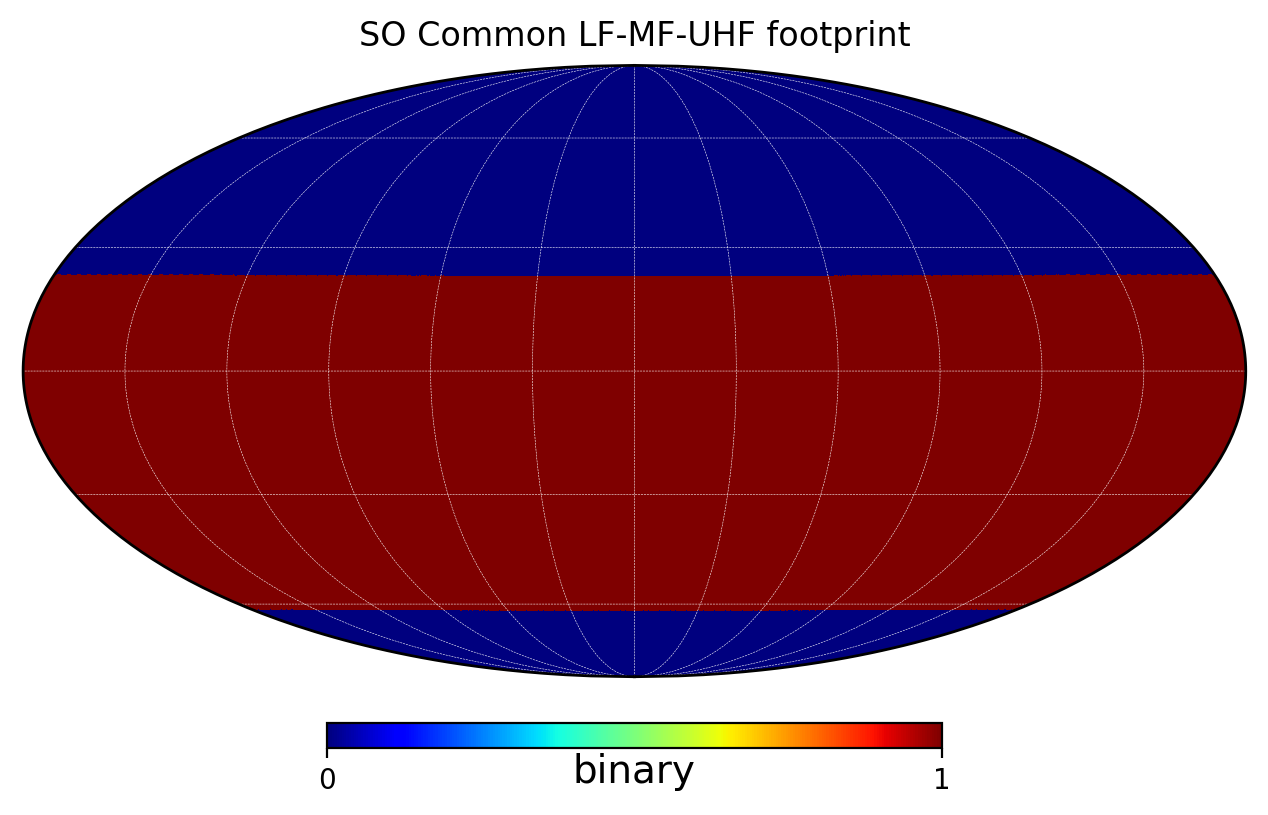

In [30]:
so_common = so_lf_bin + so_mf_bin + so_uhf_bin
so_common[so_common < 3.] = 0.
so_common[so_common >= 3.] = 1.

fig = plt.figure(dpi=200)
hp.mollview(so_common, title='SO Common LF-MF-UHF footprint', unit='binary', cmap='jet', xsize=1200, fig=fig.number)    
hp.graticule(30, 30, lw=0.2, ls='--', c='w') 

In [31]:
hp.write_map('../resources/so_lat_lf_relhits_2048.fits', so_lf_relhits, overwrite=True)
hp.write_map('../resources/so_lat_mf_relhits_2048.fits', so_mf_relhits, overwrite=True)
hp.write_map('../resources/so_lat_uhf_relhits_2048.fits', so_uhf_relhits, overwrite=True)
hp.write_map('../resources/so_lat_lf_bin_2048.fits', so_lf_bin, overwrite=True)
hp.write_map('../resources/so_lat_mf_bin_2048.fits', so_mf_bin, overwrite=True)
hp.write_map('../resources/so_lat_uhf_bin_2048.fits', so_uhf_bin, overwrite=True)
hp.write_map('../resources/so_lat_common_lf_mf_uhf_bin_2048.fits', so_common, overwrite=True)

setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
